In [103]:
import numpy as np   
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt  
import warnings 
warnings.filterwarnings('ignore')

# Data Collection

In [104]:
df = pd.read_csv('email.csv')

In [105]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Data Cleaning

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 542.3 KB


In [108]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [110]:
df.isna().sum()

Category    0
Message     0
dtype: int64

In [111]:
df.dropna(inplace=True)

In [112]:
df.drop_duplicates(inplace=True)

In [113]:
df.duplicated().sum()

np.int64(0)

# EDA

In [114]:
df.columns

Index(['Category', 'Message'], dtype='str')

In [115]:
df.shape

(5158, 2)

In [117]:
df.describe()

,Category,Message
count,5158,5158
unique,3,5158
top,ham,"Go until jurong point, crazy.. Available only ..."
freq,4516,1


In [116]:
df['Category'].value_counts()

Category
ham               4516
spam               641
{"mode":"full"       1
Name: count, dtype: int64

<Axes: xlabel='Category'>

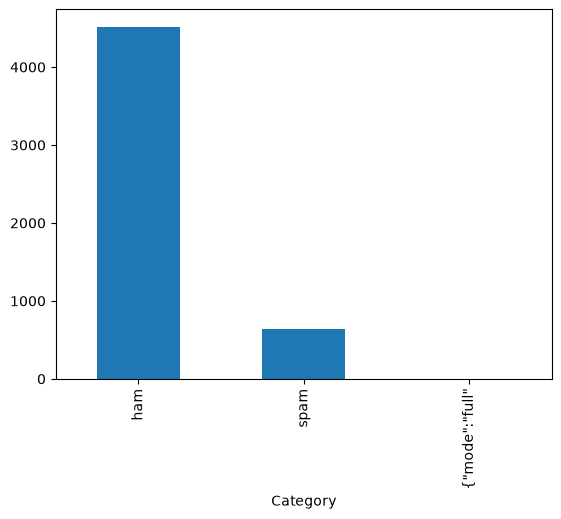

In [118]:
df['Category'].value_counts().plot(kind = 'bar')

In [119]:
df.rename(columns = {
    'Category' : 'Label' ,
    'Message' : 'text' 
} , inplace= True)

In [120]:
df.head()

,Label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [121]:
df['Label'] = df['Label'].map({
  'ham' : 0 ,
   'spam' : 1
})

In [122]:
df.head()

,Label,text
0,0.0,"Go until jurong point, crazy.. Available only ..."
1,0.0,Ok lar... Joking wif u oni...
2,1.0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0.0,U dun say so early hor... U c already then say...
4,0.0,"Nah I don't think he goes to usf, he lives aro..."


In [123]:
df

,Label,text
0,0.0,"Go until jurong point, crazy.. Available only ..."
1,0.0,Ok lar... Joking wif u oni...
2,1.0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0.0,U dun say so early hor... U c already then say...
4,0.0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,0.0,Will ü b going to esplanade fr home?
5569,0.0,"Pity, * was in mood for that. So...any other s..."
5570,0.0,The guy did some bitching but I acted like i'd...
5571,0.0,Rofl. Its true to its name


In [124]:
df.dropna(inplace=True)

In [125]:
df['Label'] = df['Label'].astype(int)

In [126]:
df.head()

,Label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [127]:
df['Label'].unique()

array([0, 1])

Text(0.5, 1.0, 'Ham or Spam')

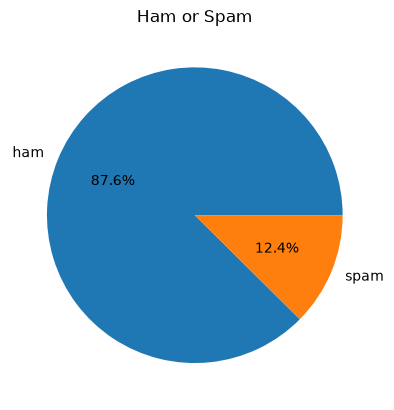

In [128]:
df['Label'].value_counts().plot(
    kind= 'pie' ,
    autopct = '%1.1f%%',
    labels = ['ham' , 'spam']
)
plt.title('Ham or Spam')

In [129]:
df['length'] = df['text'].apply(len)

In [130]:
df.head()

,Label,text,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [131]:
df['word'] = df['text'].apply(lambda x : len(x.split()))

In [132]:
df.head()

,Label,text,length,word
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [133]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [134]:
df["sentences"] = df["text"].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [135]:
df.head()

,Label,text,length,word,sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [136]:
df.groupby("Label")[["length","word","sentences"]].mean()

,length,word,sentences
Label,,,
0,70.869353,14.239814,1.827724
1,137.118565,23.659906,2.970359


# NLP

In [137]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

In [138]:
ps = PorterStemmer()

In [139]:
def transform_text(text):

    # Lowercase
    text = text.lower()

    # Tokenization
    text = nltk.word_tokenize(text)

    y = []

    # Remove special characters
    for word in text:
        if word.isalnum():
            y.append(word)

    text = y.copy()
    y.clear()

    # Remove stopwords
    for word in text:
        if word not in stopwords.words("english") and word not in string.punctuation:
            y.append(word)

    text = y.copy()
    y.clear()

    # Stemming
    for word in text:
        y.append(ps.stem(word))

    return " ".join(y)

In [140]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [141]:
transform_text("Congratulations!! You have WON ₹5000. Click here now!!")

'congratul click'

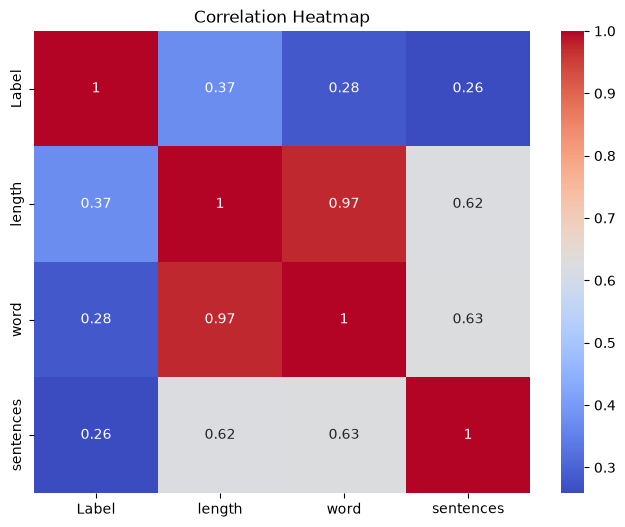

In [142]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score , classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [144]:
X = df.drop(['Label', 'text'], axis=1)
X_text = df['text']
y = df['Label']

In [145]:
X.columns

Index(['length', 'word', 'sentences'], dtype='str')

In [146]:
X_train, X_test, X_text_train , X_text_test , y_train, y_test = train_test_split(X,X_text, y, test_size=0.20, random_state=42)

# Feature Scaling

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [148]:
vectorizer = TfidfVectorizer(max_features=3000)

X_text_train_scaled = vectorizer.fit_transform(X_text_train)
X_text_test_scaled = vectorizer.transform(X_text_test)

# All Model Training Together¶

In [ ]:

models = {
    "Logistic Regression" : LogisticRegression() ,
    "KNN" : KNeighborsClassifier() ,  
    "Navie Bayes" : GaussianNB() ,  
    "Decision Tree" : DecisionTreeClassifier() ,  
    "SVM( RBF Kernel)" : SVC(probability=True)
}

In [ ]:
result = []

In [151]:
from scipy.sparse import hstack

X_train_final = hstack([X_text_train_scaled, X_train_scaled])
X_test_final = hstack([X_text_test_scaled, X_test_scaled])

In [152]:
X_train_final = X_train_final.toarray()
X_test_final = X_test_final.toarray()

In [153]:
for name , model in models.items() :
    model.fit(X_train_final , y_train)
    y_pred = model.predict(X_test_final)
    acc = accuracy_score(y_test , y_pred)
    f1 = f1_score(y_test , y_pred) 
    result.append({
        'model' : name , 
        'Accuracy' : round(acc,4)  ,
        'f1 score' : round(f1,4)
    })

In [154]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.9641, 'f1 score': 0.8604},
 {'model': 'KNN', 'Accuracy': 0.9651, 'f1 score': 0.8626},
 {'model': 'Navie Bayes', 'Accuracy': 0.8808, 'f1 score': 0.6685},
 {'model': 'Decision Tree', 'Accuracy': 0.9671, 'f1 score': 0.8759},
 {'model': 'SVM( RBF Kernel)', 'Accuracy': 0.9816, 'f1 score': 0.9266}]

In [155]:
from sklearn.linear_model import LogisticRegression
import joblib

model = LogisticRegression()

model.fit(X_text_train_scaled, y_train)

joblib.dump(model, "Logistic_Regression_email.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']